<a href="https://colab.research.google.com/github/ankxie/PHYS633/blob/main/Book/L11-SourceFunction/11-SourceFunction-template.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# <font color="purple">Notebook 11-SourceFunction</font> (template)

We start by importing the modules
* Numpy -- operations on arrays and matrixes (and pi)
* Matplotlib pyplot -- plotting library
* Matplotlin patches -- module that enables patches in plots
* Astropy units -- defined quantities with units. We also import the CDS conversions

In [2]:
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib as mpl

%matplotlib inline

from astropy import constants as const
import astropy.units as u
from astropy.units import cds
cds.enable()

## 0. To execute: Below is the function that creates a gradiant of color between two curves, according to a certain function.

In [3]:
def rect(ax,x,y,w,h,c):
    #ax = plt.gca()
    polygon = plt.Rectangle((x,y),w,h,color=c)
    ax.add_patch(polygon)

def rainbow_fill_between(ax, X, Y1, Y2, colors=None,
                         cmap=plt.get_cmap("Reds"),**kwargs):
    plt.plot(X,Y1,lw=0)  # Plot so the axes scale correctly

    dx = X[1]-X[0]
    N  = X.size

    #Pad a float or int to same size as x
    if (type(Y2) is float or type(Y2) is int):
        Y2 = np.array([Y2]*N)

    #No colors -- specify linear
    if colors is None:
        colors = []
        for n in range(N):
            colors.append(cmap(n/float(N)))
    #Varying only in x
    elif len(colors.shape) == 1:
        colors = cmap((colors-colors.min())
                      /(colors.max()-colors.min()))
    #Varying only in x and y
    else:
        cnp = np.array(colors)
        colors = np.empty([colors.shape[0],colors.shape[1],4])
        for i in range(colors.shape[0]):
            for j in range(colors.shape[1]):
                colors[i,j,:] = cmap((cnp[i,j]-cnp[:,:].min())
                                    /(cnp[:,:].max()-cnp[:,:].min()))

    colors = np.array(colors)

    #Create the patch objects
    for (color,x,y1,y2) in zip(colors,X,Y1,Y2):
        rect(ax,x,y2,dx,y1-y2,color,**kwargs)

## 1. First, let's consider a case where there is only emission.

* Note that the lenght of the slab is 4 length units.


### a. The properties of the material are constant $\rho(s)=\rho_o$ and $j(s)=j_o$.
* The product of the emission coefficient and the density give an intensity of 0.25 per unit of length.
>**TODO**: start from $dI=...$ find an equation for $I(s)$ and show your work below. Add a curve for $I(s)$ in the graph below.

$$dI = +j(s)\rho (s) ds$$
$$\int_{I_0}^{I(s)} dI = \int_{s_0}^{s}j(s)\rho (s) ds$$
We choose one of the bounds of our integral to be a location $s_0$ where we know the intensity, $I_0$ Because our density and emissivity are constant, we can pull them out of the integral, and then integrate.

$$I(s) = I_0 + j_0 \rho_0(s - s_0)$$

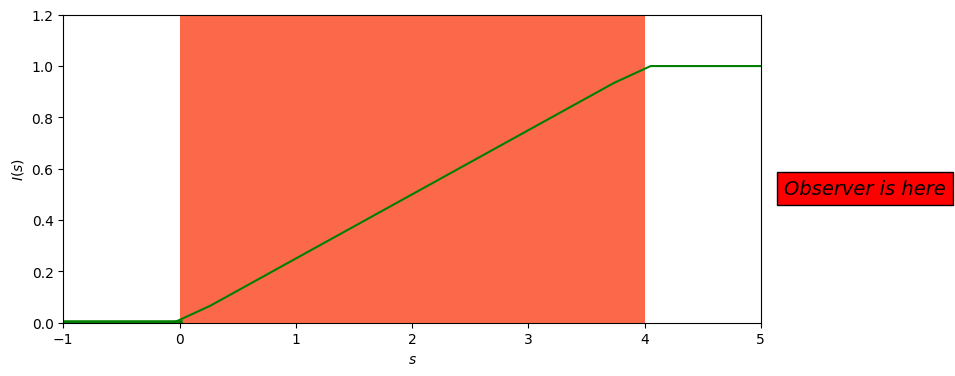

In [4]:
fig, ax = plt.subplots(1,1, figsize=(9,4))
plt.rcParams.update({'font.size': 14})

ax.set_ylim(0, 1.2)
ax.set_xlim(-1,5)

# For the first graph, I want a patch with constant color
cmap = mpl.colormaps["Reds"]
rgba = cmap(0.5) # pick the color in the center of the color map
rec = mpatches.Rectangle( (0, 0), 4 , 1.2, fc=rgba) # Create a shaded rectangle
p = ax.add_patch(rec) # add the rectangle to the plot
t = ax.text(5.2, 0.5, 'Observer is here', style='italic',
        bbox={'facecolor':'red', 'pad':5})
ax.plot([-1,0],[0,0], lw=4, c='green')
ax.set_xlabel('$s$')
ax.set_ylabel('$I(s)$')

#---------------------------------------
#---------------------------------------
# At home

def I_em(s, I0, rj, d, s0):
  I_array = []

  for i in range(len(s)):
    if s[i] <= s0:
      I_array = np.append(I_array, I0)

    if s[i] > s0 and s[i] < d + s0:
      I_array = np.append(I_array, I0 + rj * (s[i] - s0))

    if s[i] >= d + s0:
      I_array = np.append(I_array, I0 + rj * (d))

  return I_array

rhoj = 0.25
s_array = np.linspace(-1, 5, 20)
I0 = 0
s0 = 0
d = 4

ax.plot(s_array, I_em(s_array, I0, rhoj, d, s0), c = 'g')

> **TODO**: Please write a small paragraph with an interpretation of the result obtained:

In a case with only emission and constant $j\rho$, the intensity of light will increase linearly through the material. Each bit of the slab contributes the same amount of intensity per length.

### b. Now consider the emission inside a slab with density varying such that:

$$ \rho(s) = \rho_o \left( 1- \frac{s}{d} \right) $$
and for which the emiisivity is still constant $j(s)=j_o$.

>**TODO**:
>
> a. Find an expression for the intensity $I(s)$ everywhere in the slab and show your work below

$$dI = +j(s)\rho (s) ds$$
$$\int_{I_0}^{I(s)} dI = \int_{s_0}^{s}j(s)\rho (s) ds$$
Since $j(s)$ is constant, it can be pulled out of the integral, while we substitute in our equation for $\rho(s)$.

$$I(s) - I_0 = j_0 \int_{s_0}^{s} \rho_o \left( 1- \frac{s}{d} \right) ds$$
$$I(s) = I_0 + j_0\rho_0(s - s_0 - \frac{s^2 - s_0^2}{2d})$$

>
> b. Analytically, find what the value of $\rho_o j_o$ has to be for the final intensity to be the same than that of #1a. Show your work below.

$$I_{final} = 1, s_{final$} = d, s_0 = 0, d = 4$$
$$1 = j_0\rho_0(4 - \frac{16}{8})$$
$$j_0\rho_0 = \frac{1}{2}$$
>
> c. Add a curve for $I(s)$ to the graph below.

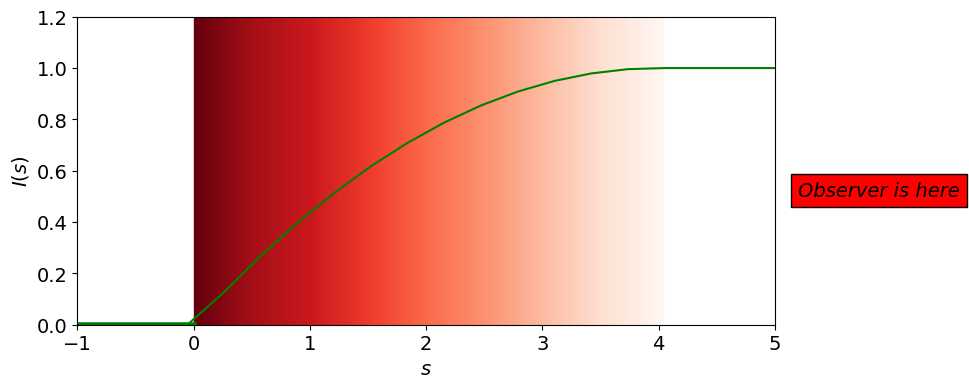

In [5]:
fig, ax = plt.subplots(1,1, figsize=(9,4))
plt.rcParams.update({'font.size': 14})

ax.set_ylim(0, 1.2)
ax.set_xlim(-1,5)

# Create a patch with a gradient to illustrate
# the change in density
X=np.linspace(0,4,100)
Y1=np.copy(X)*0
Y2=np.copy(X)*0+4
g = 1.0-np.copy(X/4)
rainbow_fill_between(ax,X,Y1,Y2,colors=g)
t = ax.text(5.2, 0.5, 'Observer is here', style='italic',
        bbox={'facecolor':'red', 'pad':5})
ax.plot([-1,0],[0,0], lw=4, c='green')
ax.set_xlabel('$s$')
ax.set_ylabel('$I(s)$')

#---------------------------------------
#---------------------------------------
# At home

def I_em(s, I0, rj, d, s0):
  I_array = []

  for i in range(len(s)):
    if s[i] <= s0:
      I_array = np.append(I_array, I0)

    if s[i] > s0 and s[i] < d + s0:
      I_array = np.append(I_array, I0 + rj * (s[i] - s0 - (s[i]**2 + s0**2)/2/d))

    if s[i] >= d + s0:
      I_array = np.append(I_array, I0 + rj * (d - ((d + s0)**2 + s0**2)/2/d))

  return I_array

rhoj = 0.5
s_array = np.linspace(-1, 5, 20)
I0 = 0
s0 = 0
d = 4

ax.plot(s_array, I_em(s_array, I0, rhoj, d, s0), c = 'g')


**TODO**: Please write a small paragraph with an interpretation of the result obtained:

The sections of the slab closer to the observer are less dense, and therefore contribute less intensity to the beam of light. That is why the slop of the line of I vs s decreases as s increases.


## 2. Now let's look at the case where there is both absorption and emission.

In class, we found the 'formal solution' of RT to be:
$$I(\tau) ~~=~~ ~ I_o\mathrm{e}^{\tau-\tau_o} ~+~ \int_{\tau'=\tau_o}^{\tau'=\tau} S(\tau')~ \mathrm{e}^{\tau-\tau'}d\tau'$$

### a. Constant source function ($S(\tau)=So$)

In this case, the , the formal solution can be written as:
$$I(s) ~~=~~ ~ I_o\mathrm{e}^{\tau(s)-\tau_o} ~+~ S_o\left[1-\mathrm{e}^{\tau(s)-\tau_o}\right]$$

Here, let's consider that everything else is also constant: $\rho(s)=\rho_o$ and $j(s)=j_o$.

Numerical values are defined in the code below.

>**TODO**:
>
> 1. Find an expression for $\tau(s)-\tau_o$. Show your work.
$$d\tau = -\kappa\rho ds$$
$$\int_{\tau_0}^{\tau} d\tau = \int_{s_0}^{s} -\kappa\rho ds$$
$$\tau(s) - \tau_0 = \kappa\rho (s_0 - s)$$
> 2. In the graph below, add a curve for the first term of the $I(s)$ equation. Make sure to add a legend.
> 3. In the graph below, add a curve for the second term of the $I(s)$ equation. Make sure to add a legend.
> 4. In the graph below, add a curve for $I(s)$ itself. Make sure to add a legend.
>
> Note: I have shown what the graph should look like in the class slides :)

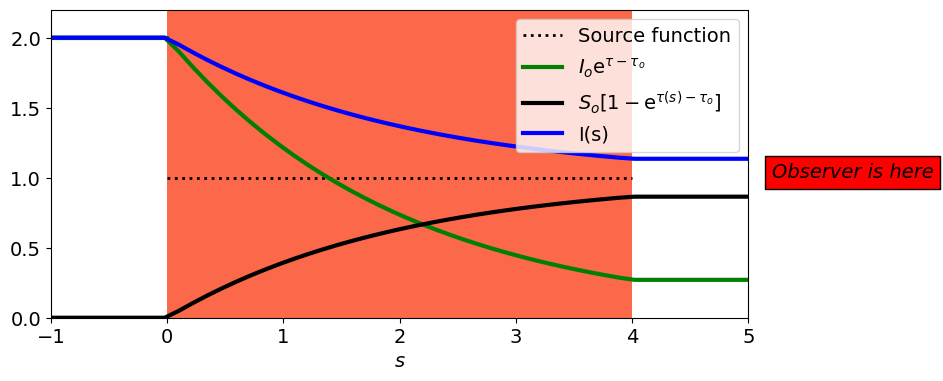

In [51]:
fig, ax = plt.subplots(1,1, figsize=(9,4))
plt.rcParams.update({'font.size': 14})

ax.set_ylim(0, 2.2)
ax.set_xlim(-1,5)

# For the first graph, I want a patch with constant color
cmap = mpl.colormaps["Reds"]
rgba = cmap(0.5) # pick the color in the center of the color map
ax.add_patch(mpatches.Rectangle( (0, 0), 4 , 2.2, fc=rgba)) # add the rectangle to the plot
ax.text(5.2, 1, 'Observer is here', style='italic',
        bbox={'facecolor':'red', 'pad':5})

ax.set_xlabel('$s$')

#---------------------------------------------------------
# Here are the values for already defined for this problem

Io = 2
j_rho = 0.5
kappa_rho = 0.5
S = j_rho / kappa_rho
d = 4
s_array = np.linspace(-1, 5, 50)

ss = np.linspace(0,4, 50)

# Curve for the source function value
ax.plot([-1,0], [Io,Io], c='green', lw=3)
source = np.array( [S]*ss.size )
ax.plot(ss, source, ls='dotted', c='k', lw=2, label='Source function')
#---------------------------------------
#---------------------------------------


# Optical depth
def diftau(s, kr, dis):
  diftau_array = []

  for i in range(len(s)):
    if s[i] <= 0:
      diftau_array = np.append(diftau_array, 0)
    if s[i] > 0 and s[i] < dis:
      diftau_array = np.append(diftau_array, kr * -1 * s[i])
    if s[i] >= dis:
      diftau_array = np.append(diftau_array, kr * -1 * dis)

  return diftau_array

# First term (if there was no emission)

def I1(s, I0, kr, dis):
  dt = diftau(s, kr, dis)
  dt_edge = diftau([dis], kr, dis)
  I_array = []

  for i in range(len(dt)):
    if dt[i] == 0:
      I_array = np.append(I_array, I0)

    if dt[i] < 0 and dt[i] > dt_edge[0]:
      I_array = np.append(I_array, I0 * np.exp(dt[i]))

    if dt[i] == dt_edge[0]:
      I_array = np.append(I_array, I0 * np.exp(dt_edge[0]))

  return I_array

ax.plot(s_array, I1(s_array, Io, kappa_rho, d), c='green', lw=3, label = r'$I_o \mathrm{e}^{\tau-\tau_o}$')


# Second term (if there was no initial intensity)

def I2(s, kr, source, dis):
  dt = diftau(s, kr, dis)
  dt_edge = diftau([dis], kr, dis)
  I_array = []

  for i in range(len(dt)):
    if dt[i] == 0:
      I_array = np.append(I_array, 0)

    if dt[i] < 0 and dt[i] > dt_edge[0]:
      I_array = np.append(I_array, source * (1 - np.exp(dt[i])))

    if dt[i] == dt_edge[0]:
      I_array = np.append(I_array, source * (1 - np.exp(dt_edge[0])))

  return I_array

ax.plot(s_array, I2(s_array, kappa_rho, S, d), c = 'k', lw = 3, label = r'$S_o\left[1-\mathrm{e}^{\tau(s)-\tau_o}\right]$')

# Intensity

ax.plot(s_array, I1(s_array, Io, kappa_rho, d) + I2(s_array, kappa_rho, S, d), c = 'b', lw = 3, label = r'$I(s)$')

#-------------
ax.legend(loc=0)

> **TODO**: Please write a small paragraph with an interpretation of the result obtained:

The total intensity converges towards the source function as the light travels through the slab. We can see that the total intensity curve equals the addition of the two components.

### b. Constant source function ($S(\tau)=So$) but linearly decreasing density

 > **TODO**: Re-do what we did in #2a, assuming this time that the density is decreasing linearly such that:
 >
>$ \rho(s) = \rho_o \left( 1- \frac{s}{d} \right), $
>
>where $d$ is the length of the slab.
>
>Note: You can directly use some of the results from your previous notebook (e.g. for the optical depth).  

In the previous notebook I derived

$$ \tau_\lambda(u) = - \rho_o \kappa_\lambda d (u - \frac{u^2}{2} - \frac{1}{2})$$

Where $u = \frac{s}{d}$.

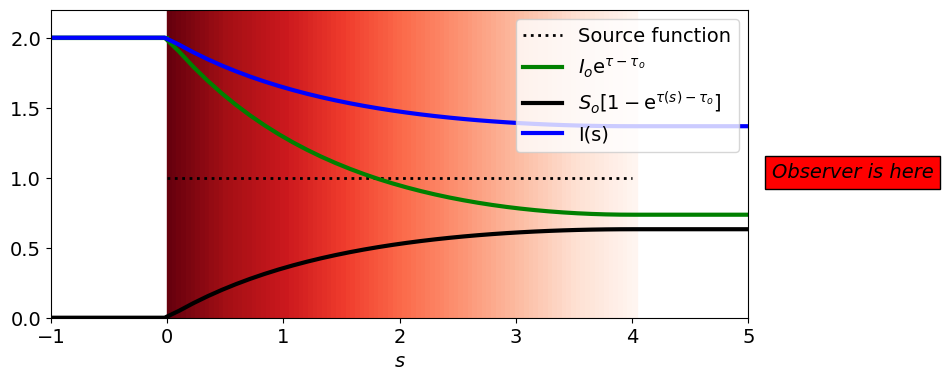

In [55]:
fig, ax = plt.subplots(1,1, figsize=(9,4))
plt.rcParams.update({'font.size': 14})

ax.set_ylim(0, 2.2)
ax.set_xlim(-1,5)


# Create a patch with a gradient to illustrate
# the change in density
X=np.linspace(0,4,100)
Y1=np.copy(X)*0
Y2=np.copy(X)*0+4
g = 1.0-np.copy(X/4)
rainbow_fill_between(ax,X,Y1,Y2,colors=g)

ax.text(5.2, 1, 'Observer is here', style='italic',
        bbox={'facecolor':'red', 'pad':5})

ax.set_xlabel('$s$')

#---------------------------------------------------------
# Here are the values for already defined for this problem

Io = 2
j_rho = 0.5
kappa_rho = 0.5
S = j_rho / kappa_rho
d = 4

ss = np.linspace(0,4, 50)

# Curve for the source function value
ax.plot([-1,0], [Io,Io], c='green', lw=3)
source = np.array( [S]*ss.size )
ax.plot(ss, source, ls='dotted', c='k', lw=2,label='Source function')
#---------------------------------------
#---------------------------------------

def x(s, dis):
  return s/dis

def diftau(s, kr, dis):
  tau_0 = 0.5 *kr * dis
  #print(tau_0)

  diftau_array = []

  for i in range(len(s)):
    u = x(s[i], dis)

    if u <= 0:
      diftau_array = np.append(diftau_array, 0)

    if u > 0 and u < 1:
      diftau_array = np.append(diftau_array, -1 * kr * dis * (u - 0.5*u**2 - 0.5) - tau_0)

    if u >= 1:
      diftau_array = np.append(diftau_array, -1* tau_0)

  return diftau_array

# First term (if there was no emission)

def I1(s, I0, kr, dis):
  dt = diftau(s, kr, dis)
  dt_edge = diftau([dis], kr, dis)
  I_array = []

  for i in range(len(dt)):
    if dt[i] == 0:
      I_array = np.append(I_array, I0)

    if dt[i] < 0 and dt[i] > dt_edge[0]:
      I_array = np.append(I_array, I0 * np.exp(dt[i]))

    if dt[i] == dt_edge[0]:
      I_array = np.append(I_array, I0 * np.exp(dt_edge[0]))

  return I_array

ax.plot(s_array, I1(s_array, Io, kappa_rho, d), c='green', lw=3, label = r'$I_o \mathrm{e}^{\tau-\tau_o}$')


# Second term (if there was no initial intensity)

def I2(s, kr, source, dis):
  dt = diftau(s, kr, dis)
  dt_edge = diftau([dis], kr, dis)
  I_array = []

  for i in range(len(dt)):
    if dt[i] == 0:
      I_array = np.append(I_array, 0)

    if dt[i] < 0 and dt[i] > dt_edge[0]:
      I_array = np.append(I_array, source * (1 - np.exp(dt[i])))

    if dt[i] == dt_edge[0]:
      I_array = np.append(I_array, source * (1 - np.exp(dt_edge[0])))

  return I_array

ax.plot(s_array, I2(s_array, kappa_rho, S, d), c = 'k', lw = 3, label = r'$S_o\left[1-\mathrm{e}^{\tau(s)-\tau_o}\right]$')

# Intensity

ax.plot(s_array, I1(s_array, Io, kappa_rho, d) + I2(s_array, kappa_rho, S, d), c = 'b', lw = 3, label = r'$I(s)$')


#---------------------------------------
ax.legend(loc=0)

**TODO**: Please write a small paragraph with an interpretation of the result obtained:

Compared to what we found in #2a, the intensity does not get as close to the source function before the light exits the slab. This makes sense because the density of the slab decreases. Therefore, there is "less slab" available to change the intensity to be closer to the source function.  

## 3. Case when the source function is not constant.

Let's assume that the density and opacity in the slab are constant, such that $\kappa_o\rho_o=2.0$ per unit length.

The source function is however a function of $\tau$ such that:
$$ S(\tau) = S_0 + S_1\tau$$
where $S_0=0.5$ intensity unit, and $S_1=1.3$ intensity units per optical depth unit.

There is no intial intensity entering the slab so $I_o = 0$.

Prepare your code such that you can vary the values of the paramters in the equations above.

### a. Find an expression for $I(\tau)$.
>**TODO**: In this case, you cannot use the expression we found for the constant source function. You will have to start back at the expression for the formal solution itself:
>
>$I(\tau) ~=~ ~ I_o\mathrm{e}^{\tau-\tau_o} ~+~ \int_{\tau'=\tau}^{\tau'=\tau_o} S(\tau')~ \mathrm{e}^{\tau-\tau'}d\tau'.$
>
>But thankfully, given that $\rho(s)=\rho_o$ and $\kappa(s)=\kappa_o$, you can use your previous results for $\tau(s)$ for constant opacity and density.
>
>Show your work below

$$u = \frac{s}{d}$$
$$ \tau_\lambda(u) = - \rho_o \kappa_\lambda d (u - \frac{u^2}{2} - \frac{1}{2})$$

$$\tau_o = \tau_\lambda(0) =  \frac{\rho_o \kappa_\lambda d}{2}$$

$$I(\tau) ~=~ ~ I_o\mathrm{e}^{\tau-\tau_o} ~+~ \int_{\tau'=\tau}^{\tau'=\tau_o} (S_0 + S_1\tau')~ \mathrm{e}^{\tau-\tau'}d\tau'$$

$$I(\tau) ~=~ ~ I_o\mathrm{e}^{\tau-\tau_o} ~+~ S_0\left[1-\mathrm{e}^{\tau-\tau_o}\right] ~+~ S_1\mathrm{e}^{\tau}[-\mathrm{e}^{-\tau_o}(\tau_o + 1) + \mathrm{e}^{-\tau}(\tau + 1)]$$
$$I(\tau) ~=~ ~ I_o\mathrm{e}^{\tau-\tau_o} ~+~ S_0\left[1-\mathrm{e}^{\tau-\tau_o}\right] ~+~ S_1[-\mathrm{e}^{\tau-\tau_o}(\tau_o + 1) + (\tau + 1)]$$

$$I_o = 0$$

$$I(\tau) ~=~  S_0\left[1-\mathrm{e}^{\tau-\tau_o}\right] ~+~ S_1[-\mathrm{e}^{\tau-\tau_o}(\tau_o + 1) + (\tau + 1)]$$

### b. On your graph add a curve for:
>**TODO**:
>1. the optical depth $\tau$ as a function of $s$.
>2. the source function $S$ as a function of $s$.
>3. the intensity $I$ as a function of $s$.
>
>4. Concentrating on the side of your graph where the light exits the slab, estimate the optical depth at which the value of the source function is equal to the value of the intensity emerging from the slab.

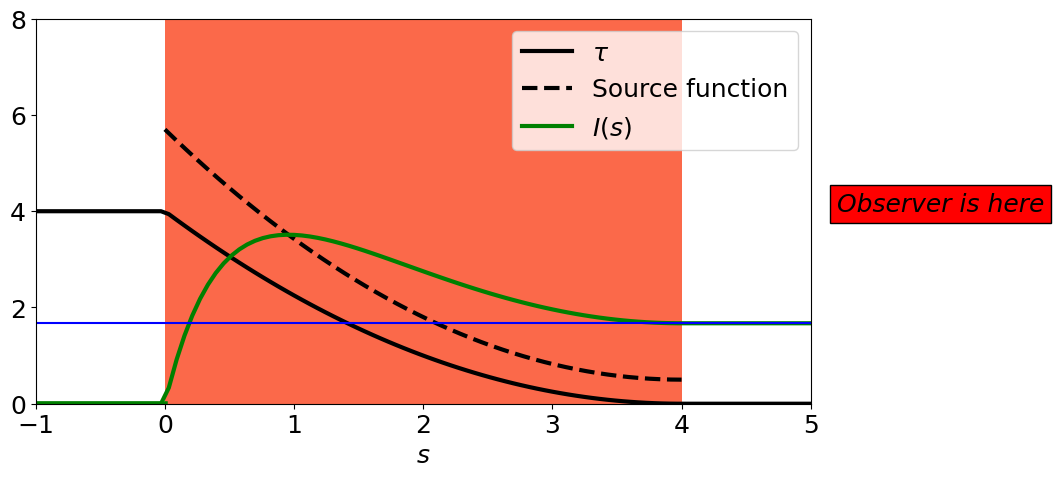

In [89]:
fig, ax = plt.subplots(1,1, figsize=(10,5))
plt.rcParams.update({'font.size': 18})

ax.set_ylim(0, 8)
ax.set_xlim(-1,5)

# For the first graph, I want a patch with constant color
cmap = mpl.colormaps["Reds"]
rgba = cmap(0.5) # pick the color in the center of the color map
rec = mpatches.Rectangle( (0, 0), 4 , 8, fc=rgba) # Create a shaded rectangle
ax.add_patch(rec) # add the rectangle to the plot
ax.text(5.2, 4, 'Observer is here', style='italic',
        bbox={'facecolor':'red', 'pad':5})

ax.set_xlabel('$s$')

# Values to use

d = 4

Io = 0
kappa_rho = 2.0

S0 = 0.5
S1 = 1.3

s_array = np.linspace(-1, 5, 100)
ss = np.linspace(0,4, 50)
ax.plot([-1,0],[0,0], lw=4, c='green')

#---------------------------------------
#---------------------------------------
# At home

def x(s, dis):
  return s/dis

#optical depth
def tau(s, kr, dis):

  tau_array = []

  for i in range(len(s)):
    u = x(s[i], dis)

    if u <= 0:
      tau_array = np.append(tau_array, -1 * kr * dis * (- 0.5))

    if u > 0 and u < 1:
      tau_array = np.append(tau_array, -1 * kr * dis * (u - 0.5*u**2 - 0.5))

    if u >= 1:
      tau_array = np.append(tau_array, 0)

  return tau_array

ax.plot(s_array, tau(s_array, kappa_rho, d), c = 'k', lw = 3, label = r'$\tau$')

#Source function

def source(s, kr, dis, S0, S1):
  t = tau(s, kr, dis)

  source_array = S0 + S1 * t

  return source_array

ax.plot(ss, source(ss, kappa_rho, d, S0, S1), c = 'k', linestyle = '--', lw = 3, label = 'Source function')

#Intensity
def I_tot(s, kr, dis, S0, S1):
  t = tau(s, kr, dis)
  t0 = tau([0], kr, dis)[0]
  dt = t - t0
  dt_edge = tau([dis], kr, dis) - t0
  I_array = []

  for i in range(len(dt)):
    if dt[i] == 0:
      I_array = np.append(I_array, 0)

    if dt[i] < 0 and dt[i] > dt_edge[0]:
      I_array = np.append(I_array,  S0 * (1 - np.exp(dt[i])) + S1 * (-np.exp(dt[i]) * (t0 + 1) + (t[i] + 1)))
      #I_array = np.append(I_array, S1 * (-np.exp(dt[i]) * (t0 + 1) + (t[i] + 1)))
      #I_array = np.append(I_array,  S0 * (1 - np.exp(dt[i])))

    if dt[i] == dt_edge[0]:
      I_array = np.append(I_array,  S0 * (1 - np.exp(dt_edge[0])) + S1 * (-np.exp(dt_edge[0]) * (t0 + 1) + (t[i] + 1)))
      #I_array = np.append(I_array,  S1 * (-np.exp(dt_edge[0]) * (t0 + 1) + (t[i] + 1)))
      #I_array = np.append(I_array,  S0 * (1 - np.exp(dt_edge[0])))

  return I_array

#print(I_tot(s_array,kappa_rho, d, S0, S1))
ax.plot(s_array, I_tot(s_array,kappa_rho, d, S0, S1), c = 'g', lw = 3, label = r'$I(s)$')

ax.axhline(y = I_tot(s_array,kappa_rho, d, S0, S1)[-1], c = 'b')

ax.legend(loc=0)


The source function equals the value of the intensity emerging from the slab around where optical depth equals 1.

> **TODO**: Please write a small paragraph with an interpretation of the result obtained (hint: remember what the intensity aspires to become :):

Intensity aspires to become equal to the source function. The value of intensity emerging from the slab equals the value of the source function around where $\tau \approx 1$. Therefore, the value of intensity emerging from the slab tells us something about the slab's properties around $\tau \approx 1$. Between $\tau \approx 1$ and the edge of the slab, we can treat the light as if it had only been absorbed (with no emission added). In other words, as if the intensity was following $I(\tau) = I(\tau_0)\mathrm{e}^{\tau-\tau_0}$, where $\tau_0 \approx 1$. We can do this because both our "real" intensity function, and our "absorption only" intensity function converge to the observed, emerging intensity.
